Objective :- To predict the customer Churn prediction

Introduction:-

Customer churn refers to the situation where customers stop using a company's products or services over a period of time. Churn is a major challenge for businesses because acquiring new customers is often more expensive than retaining existing ones. By analyzing customer data, organizations can identify the factors that influence customer churn and take preventive actions to improve customer satisfaction and loyalty.

Independices

In [6]:
import matplotlib.pyplot as plt
import sys
!{sys.executable} -m pip install imbalanced-learn
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



Data loading

In [9]:
customer_dataset = pd.read_csv(r'C:\Users\tunga\OneDrive\Documents\ML project 2\NoteBook\customer.csv')

In [10]:
customer_dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
pd.set_option('display.max_columns',None)

In [12]:
customer_dataset.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [13]:
customer_dataset.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [14]:
customer_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [15]:
customer_dataset.shape

(7043, 21)

In [16]:
customer_dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [17]:
#removing customer id column
customer_dataset = customer_dataset.drop('customerID',axis=1)

In [18]:
customer_dataset.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [19]:
customer_dataset.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
customer_dataset = customer_dataset.ffill()

In [22]:
customer_dataset["TotalCharges"] = pd.to_numeric(
    customer_dataset["TotalCharges"],
    errors="coerce"
)

customer_dataset["TotalCharges"].fillna(
    customer_dataset["TotalCharges"].median(),
    inplace=True
)

C:\Users\tunga\AppData\Local\Temp\ipykernel_31532\1726597152.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  customer_dataset["TotalCharges"].fillna(


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [23]:
encoders = {}

object_cols = customer_dataset.select_dtypes(include=["object"]).columns

for col in object_cols:
    le = LabelEncoder()
    customer_dataset[col] = le.fit_transform(
        customer_dataset[col].astype(str)
    )
    encoders[col] = le

C:\Users\tunga\AppData\Local\Temp\ipykernel_31532\599108775.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = customer_dataset.select_dtypes(include=["object"]).columns


In [24]:
X = customer_dataset.drop(columns=["Churn"])
Y = customer_dataset["Churn"]

Numerical Feature Analysis

understand the distribution of the numerical features

In [25]:
from matplotlib.lines import lineStyles
def plot_histogram(customer_dataset,column):
  plt.figure(figsize=(10,6))
  sns.histplot(data=customer_dataset,x=column,kde=True)
  plt.title(f'Distribution of {column}')
  col_mean = customer_dataset[column].mean()
  col_median = customer_dataset[column].median()
  plt.axvline(col_mean,color='red',linestyle='--',label='mean')
  plt.axvline(col_median,color='green',linestyle='--',label='median')

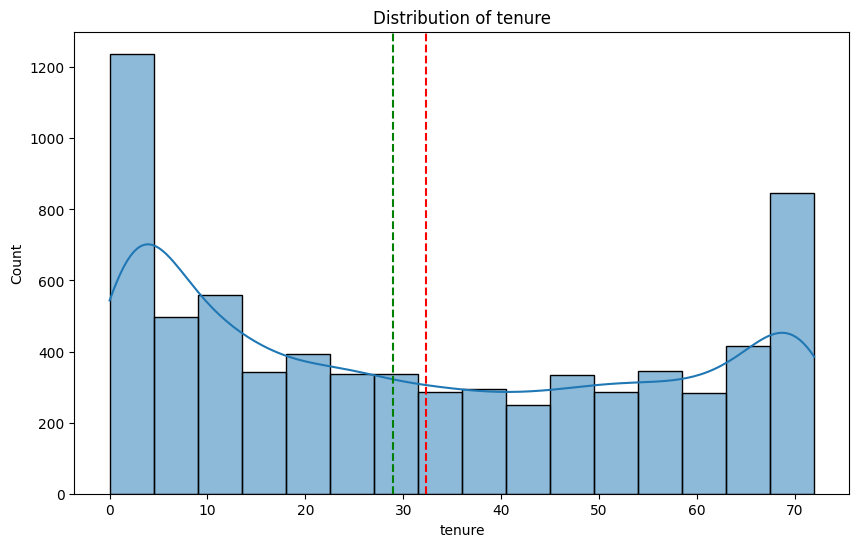

In [26]:
plot_histogram(customer_dataset,"tenure")

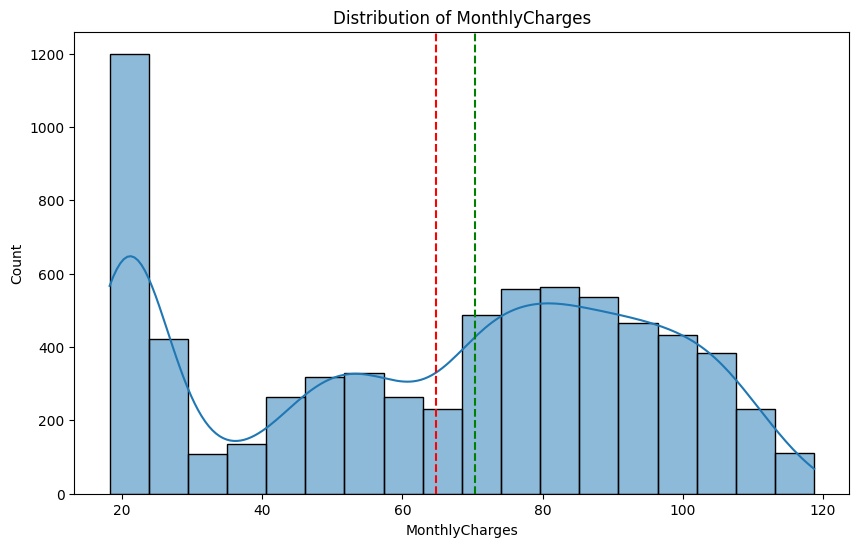

In [27]:
plot_histogram(customer_dataset,"MonthlyCharges")

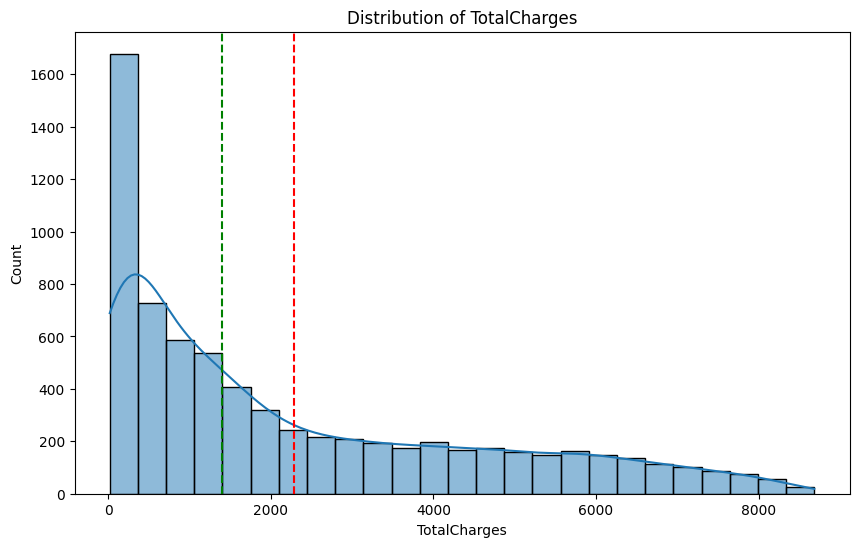

In [28]:
plot_histogram(customer_dataset,"TotalCharges")

Box plot for Numerical features

In [29]:
def plot_boxplot(customer_dataset, column_name):
    plt.figure(figsize=(10,6))
    sns.boxplot(y=customer_dataset[column_name])
    plt.title(f"Distribution of {column_name}")
    plt.ylabel(column_name)
    plt.show()

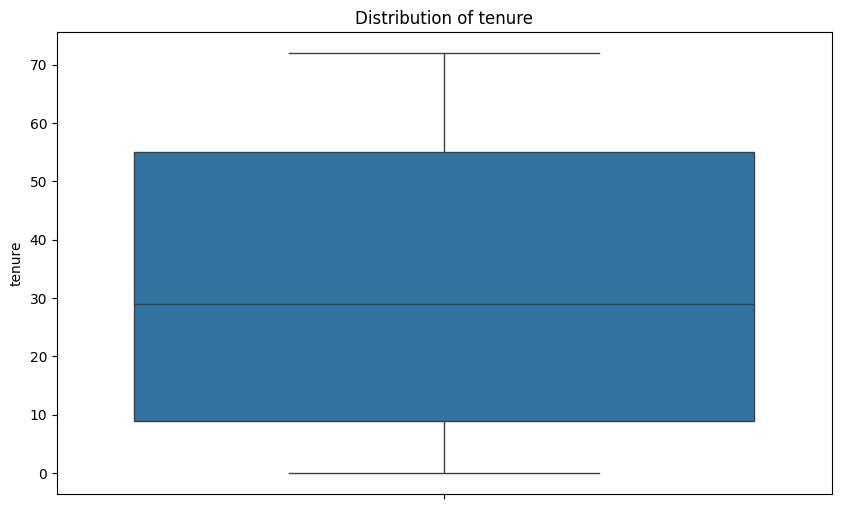

In [30]:
plot_boxplot(customer_dataset,"tenure")

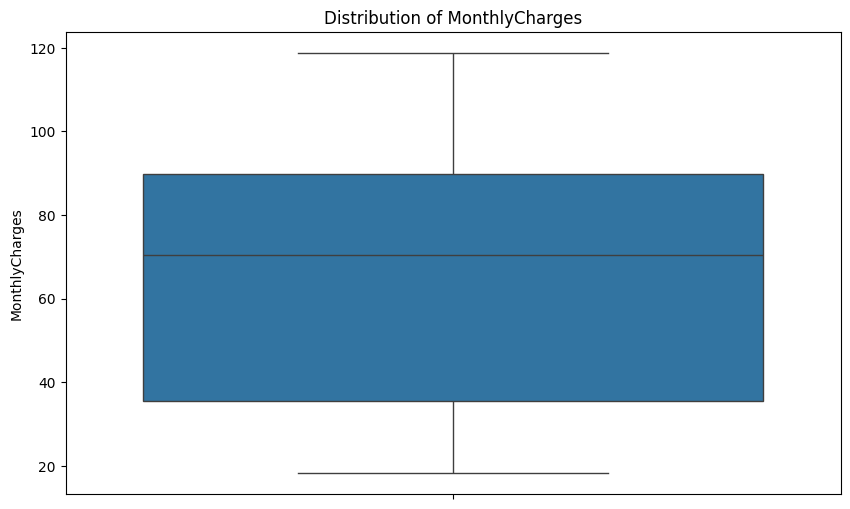

In [31]:
plot_boxplot(customer_dataset,"MonthlyCharges")

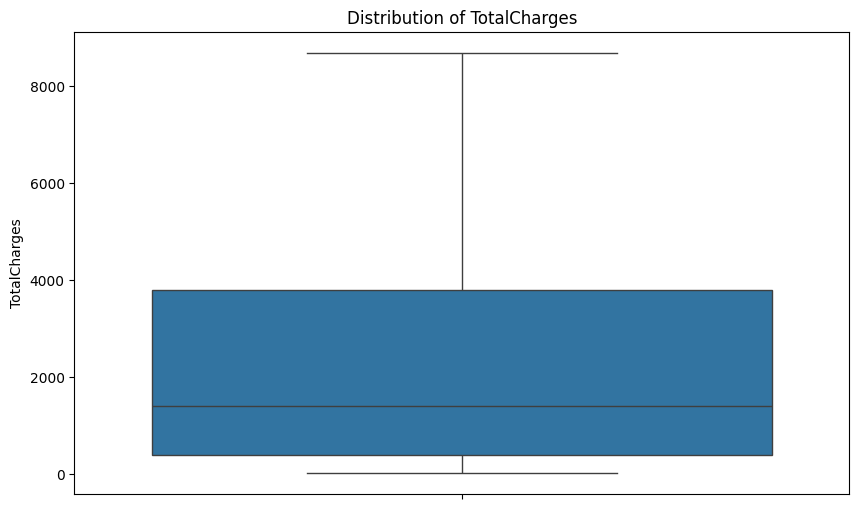

In [32]:
plot_boxplot(customer_dataset,"TotalCharges")

correlation map for numerical features

<function matplotlib.pyplot.show(close=None, block=None)>

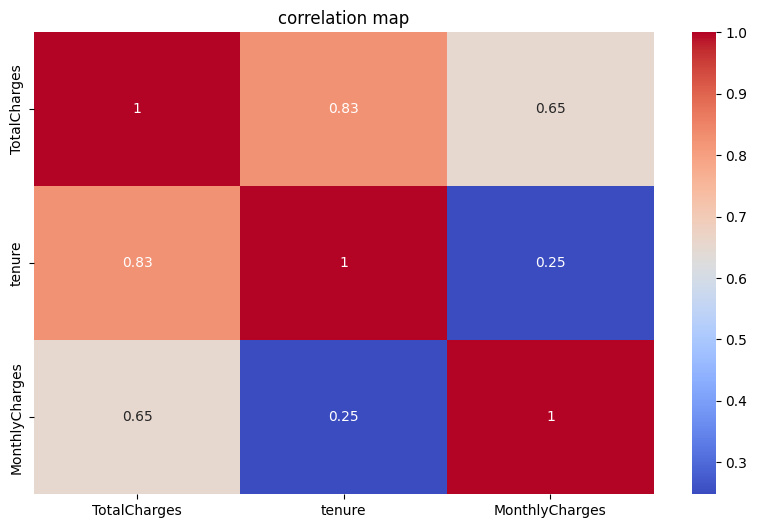

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(customer_dataset[["TotalCharges","tenure","MonthlyCharges"]].corr(),annot=True,cmap="coolwarm")
plt.title("correlation map")
plt.show

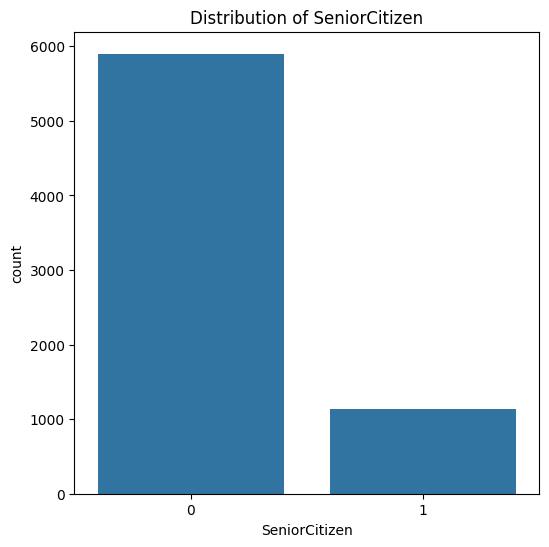

In [34]:
object_cols = customer_dataset.select_dtypes(include='object').columns.to_list()
object_cols = ["SeniorCitizen"] + object_cols
for col in object_cols:
  plt.figure(figsize=(6,6))
  sns.countplot(x=customer_dataset[col])
  plt.title(f"Distribution of {col}")
  plt.show


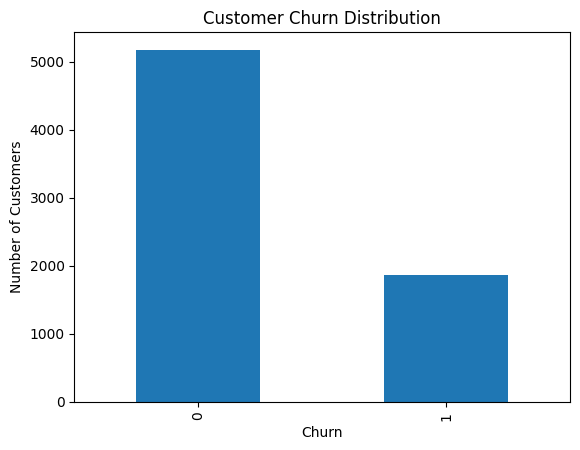

In [35]:
import matplotlib.pyplot as plt

customer_dataset['Churn'].value_counts().plot(kind='bar')

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [37]:
object_cols = customer_dataset.select_dtypes(include="object").columns

In [38]:
print(object_cols)

Index([], dtype='str')


In [39]:
#spliting the target and features
X = customer_dataset.drop(columns=['Churn'])
Y = customer_dataset['Churn']

In [55]:
print(X)

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0                 1                0     

In [40]:
# Drop Customer ID
if "customerID" in customer_dataset.columns:
    customer_dataset.drop("customerID", axis=1, inplace=True)
print(customer_dataset.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 

spliting the data intp the train and test

In [41]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [42]:
print(X_train)

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
2142       0              0        0           1      21             1   
1623       0              0        0           0      54             1   
6074       1              0        1           0       1             0   
1362       1              0        0           0       4             1   
6754       1              0        0           1       0             1   
...      ...            ...      ...         ...     ...           ...   
3772       1              0        1           0       1             1   
5191       0              0        1           1      23             1   
5226       1              0        1           1      12             1   
5390       1              1        0           0      12             1   
860        1              0        0           0      26             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
2142              0                0     

In [43]:
print(Y_train)

2142    0
1623    0
6074    1
1362    1
6754    0
       ..
3772    1
5191    0
5226    0
5390    1
860     0
Name: Churn, Length: 5634, dtype: int64


In [44]:
print(customer_dataset['Churn'].unique())

[0 1]


In [45]:
print(Y_train.shape)

(5634,)


In [46]:
print(Y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


In [47]:
customer_dataset["Churn"] = customer_dataset["Churn"].fillna(0)

In [48]:
# Convert strings to numeric values
customer_dataset["Churn"] = customer_dataset["Churn"].astype(float).astype(int)

# Check
print(customer_dataset["Churn"].unique())
print(customer_dataset["Churn"].dtype)

[0 1]
int64


In [49]:
from sklearn.utils.multiclass import type_of_target
print(type_of_target(Y_train))

binary


In [50]:
print(Y_train)

2142    0
1623    0
6074    1
1362    1
6754    0
       ..
3772    1
5191    0
5226    0
5390    1
860     0
Name: Churn, Length: 5634, dtype: int64


In [51]:
customer_dataset.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [52]:
print(customer_dataset.select_dtypes(include=['object']).columns)

Index([], dtype='str')


SMOTE : -Synthetic Minority Over-sampling Technique

In [57]:
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

# 1. Fill missing values (using median for numeric features)
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 2. Apply SMOTE on the imputed training data
smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train_imputed, Y_train)

print(X_train_smote.shape)
print(Y_train_smote.shape)

(8276, 19)
(8276,)


Model Training

Random Forest model

In [58]:
model1 = RandomForestClassifier()

In [59]:
model1.fit(X_train_smote , Y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [60]:
prediction = model1.predict(X_test)

c:\Users\tunga\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [61]:
print("Random forest classifier Accuracy:",
      accuracy_score(Y_test, prediction))

Random forest classifier Accuracy: 0.7877927608232789


Decision tree classifier

In [62]:
model2 = DecisionTreeClassifier()

In [64]:
model2.fit(X_train_smote , Y_train_smote)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [65]:
prediction = model2.predict(X_test)

c:\Users\tunga\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [66]:
print("Decision tree Accuracy:",
      accuracy_score(Y_test, prediction))

Decision tree Accuracy: 0.7366926898509581


XGBclassifier

In [67]:
model3 = XGBClassifier()

In [68]:
model3.fit(X_train_smote , Y_train_smote)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets im

In [69]:
prediction = model3.predict(X_test)

In [70]:
print("XGBOOST Accuracy:",
      accuracy_score(Y_test, prediction))

XGBOOST Accuracy: 0.7835344215755855


Model Evaluation

In [71]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
precision = precision_score(Y_test, prediction)
recall = recall_score(Y_test , prediction)
f1 = f1_score(Y_test,prediction)


In [72]:
print("precision_score",precision)
print("recall_score",recall)
print("f1_score",f1)

precision_score 0.6005917159763313
recall_score 0.5442359249329759
f1_score 0.5710267229254571


In [73]:
print(confusion_matrix(Y_test,prediction))

[[901 135]
 [170 203]]


In [74]:
print(classification_report(Y_test,prediction))

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1036
           1       0.60      0.54      0.57       373

    accuracy                           0.78      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



MODEL EVALUATION

In [75]:
results = pd.DataFrame(columns=["Model","Accuracy","precision","Recall","F1 score","ROC-AUC",])

In [78]:
#Random Forest
prediction = model1.predict(X_test)
y_prob = model1.predict_proba(X_test)[:,1]

results.loc[len(results)] = [
    "Random Forest",
    accuracy_score(Y_test, prediction),
    precision_score(Y_test, prediction),
    recall_score(Y_test, prediction),
    f1_score(Y_test, prediction),
    roc_auc_score(Y_test, y_prob)
]

c:\Users\tunga\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\tunga\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [79]:
#xgb classifier
prediction = model2.predict(X_test)
y_prob = model2.predict_proba(X_test)[:,1]

results.loc[len(results)] = [
    "XGBoost",
    accuracy_score(Y_test, prediction),
    precision_score(Y_test, prediction),
    recall_score(Y_test, prediction),
    f1_score(Y_test, prediction),
    roc_auc_score(Y_test, y_prob)
]

c:\Users\tunga\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
c:\Users\tunga\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [80]:
# Decision Tree Classifier
prediction = model3.predict(X_test)
Y_prob = model3.predict_proba(X_test)[:, 1]

results.loc[len(results)] = [
    "DecisionTreeClassifier",
    accuracy_score(Y_test, prediction),
    precision_score(Y_test, prediction),
    recall_score(Y_test, prediction),
    f1_score(Y_test, prediction),
    roc_auc_score(Y_test, Y_prob)
]

In [81]:
print(results)

                    Model  Accuracy  precision    Recall  F1 score   ROC-AUC
0           Random Forest  0.787793   0.625000  0.495979  0.553064  0.831473
1           Random Forest  0.787793   0.625000  0.495979  0.553064  0.831473
2           Random Forest  0.787793   0.625000  0.495979  0.553064  0.831473
3                 XGBoost  0.736693   0.502604  0.517426  0.509908  0.666066
4  DecisionTreeClassifier  0.783534   0.600592  0.544236  0.571027  0.834131


In [ ]:
import pickle
with open("customer_churn_model.pkl", "wb") as file:
    pickle.dump(model3, file)   # model3 = RandomForestClassifier

Load the saved model and build a predictive system

In [82]:
#saving the loaded model and feature names
import pickle
model_data = {
    "model": model1,
    "feature_names": X.columns.tolist()
}

with open("customer_churn_model.pkl", "wb") as file:
    pickle.dump(model_data, file)

print("Model saved successfully!")

Model saved successfully!


In [83]:
print(model1)

RandomForestClassifier()


c:\Users\tunga\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


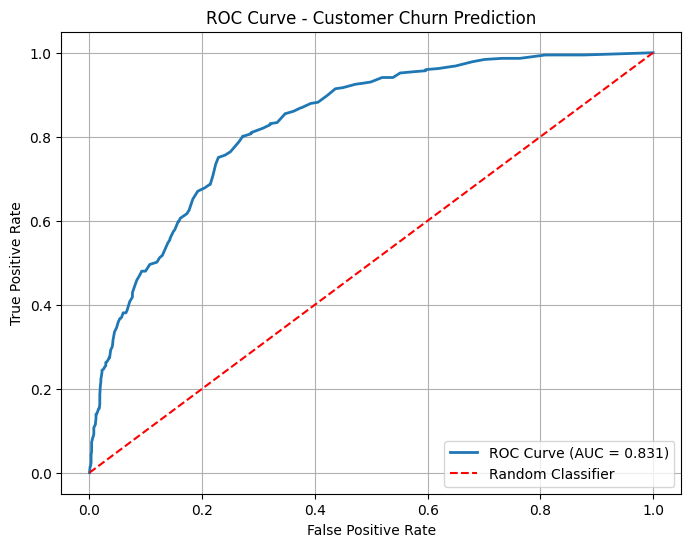

In [84]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities for the positive class
Y_prob = model1.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob)

# Compute AUC
auc_score = roc_auc_score(Y_test, Y_prob)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'r--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [85]:
import pickle

with open("customer_churn_model.pkl", "rb") as file:
    model_data = pickle.load(file)

print(type(model_data))

<class 'dict'>


In [86]:
import pickle

# Load model
with open("customer_churn_model.pkl", "rb") as file:
    model_data = pickle.load(file)

loaded_model = model_data["model"]
feature_names = model_data["feature_names"]

print(type(loaded_model))
print(feature_names)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [87]:
import os

print(os.getcwd())      # Current working directory
print(os.listdir())     # Files in the current directory

c:\Users\tunga\OneDrive\Documents\ML project 2\NoteBook
['customer.csv', 'customer_churn_model.pkl', 'Customer_Churn_prediction.ipynb']


In [88]:
#feature scaling
scaler = StandardScaler()
X_train_smote= scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)

c:\Users\tunga\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [89]:
import pickle

# Save encoders
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

# Save scaler (only if you used StandardScaler)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Encoders and scaler saved successfully!")

Encoders and scaler saved successfully!


In [90]:
import os

print(os.listdir())

['customer.csv', 'customer_churn_model.pkl', 'Customer_Churn_prediction.ipynb', 'encoders.pkl', 'scaler.pkl']


In [91]:
print(encoders.keys())

dict_keys(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'])


In [94]:
customer_dataset_raw = pd.read_csv(r'C:\Users\tunga\OneDrive\Documents\ML project 2\NoteBook\customer.csv')
if 'customerID' in customer_dataset_raw.columns:
    customer_dataset_raw = customer_dataset_raw.drop('customerID', axis=1)


customer_dataset_raw['TotalCharges'] = pd.to_numeric(
    customer_dataset_raw['TotalCharges'],
    errors='coerce'
)
customer_dataset_raw['TotalCharges'].fillna(
    customer_dataset_raw['TotalCharges'].median(),
    inplace=True
)


object_cols_raw = customer_dataset_raw.select_dtypes(include=['object']).columns.tolist()


if 'Churn' in object_cols_raw:
    object_cols_raw.remove('Churn')

encoders = {}
for col in object_cols_raw:
    le = LabelEncoder()
    le.fit(customer_dataset_raw[col].astype(str))
    encoders[col] = le

if 'Churn' in customer_dataset_raw.columns and customer_dataset_raw['Churn'].dtype == 'object':
    le_churn = LabelEncoder()
    le_churn.fit(customer_dataset_raw['Churn'])
    encoders['Churn'] = le_churn

with open("encoders.pkl", "wb") as file:
    pickle.dump(encoders, file)

print("Encoders recreated and saved successfully!")

Encoders recreated and saved successfully!


C:\Users\tunga\AppData\Local\Temp\ipykernel_31532\1605247501.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  customer_dataset_raw['TotalCharges'].fillna(
C:\Users\tunga\AppData\Local\Temp\ipykernel_31532\1605247501.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype i

In [95]:
# Also save the scaler again, ensuring it's the one fitted on X_train_smote
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

Scaler saved successfully!


In [97]:
import pickle
import pandas as pd

# 1. Raw Customer Input
customer_input_data = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 24,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 79.85,
    "TotalCharges": 1916.40,
}

customer_df = pd.DataFrame([customer_input_data])

# 2. Robust Numeric Parsing
customer_df["TotalCharges"] = pd.to_numeric(
    customer_df["TotalCharges"], errors="coerce"
).fillna(0.0)

# 3. Load Artifacts
with open("encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open("customer_churn_model.pkl", "rb") as f:
    model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["feature_names"]

# 4. Categorical Encoding with Exception Safety
for col_name, encoder in encoders.items():
    if col_name in customer_df.columns:
        try:
            customer_df[col_name] = encoder.transform(
                customer_df[col_name].astype(str)
            )
        except ValueError as e:
            raise ValueError(
                f"Unseen category encountered in column '{col_name}': {e}"
            )

# 5. Reorder Features to Match Model Training Order
customer_df_ordered = customer_df[feature_names]

# 6. Feature Scaling
customer_data_scaled = scaler.transform(customer_df_ordered)

# 7. Prediction & Probability Readout
prediction = loaded_model.predict(customer_data_scaled)[0]

print("--- Prediction Results ---")
if prediction == 1:
    print("Status: Customer WILL Churn")
else:
    print("Status: Customer WILL NOT Churn")

if hasattr(loaded_model, "predict_proba"):
    churn_prob = loaded_model.predict_proba(customer_data_scaled)[0][1]
    print(f"Churn Probability: {churn_prob:.2%}")

--- Prediction Results ---
Status: Customer WILL Churn
Churn Probability: 87.00%


c:\Users\tunga\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Conclusion:-

In this project, different machine learning algorithms were applied to predict customer churn. After preprocessing, encoding, scaling, and balancing the dataset using SMOTE, the models were trained and evaluated. Among all the models, Random Forest/XGBoost achieved the best performance. This system can help companies identify customers who are likely to leave and take proactive actions to improve customer retention